In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
df = pd.read_parquet("../../data/processed/df_final_com_topicos.parquet")
display(df)

,id,score,text,text_clean,subreddit,depth,author,topico_dominante
0,1j3g0q5,107449,Trudeau - ''I want to speak first directly to ...,trudeau want speak first directly american peo...,popculture,0,RoyalChris,7
1,1jdfbt3,57062,Kim Kardashian endorses Nazi Elon Musk’s cyber...,kardashian endorses nazi elon musk cybertruck ...,popculture,0,wyokiddo,7
2,1k7jcux,27509,Candace Owens saying she no longer supports Do...,candace owen long support donald trump,popculture,0,skyisscary,7
3,1ilwij6,23908,Kendrick Lamar called out for no white perform...,kendrick lamar call white performer super bowl...,popculture,0,IrishStarUS,9
4,1jfzx63,23502,"Elon Musk's daughter, Vivian Wilson, stars in ...",elon musk daughter vivian wilson star first ev...,popculture,0,RoyalChris,2
...,...,...,...,...,...,...,...,...
1665366,14ifnii,537,iVentoy is out now! Ease of Ventoy with just o...,iventoy ease ventoy iventoy release exactly se...,selfhosted,1,Floroform,3
1665367,zqyg79,536,I created a library of full-color SVG icons of...,create library full color icon homelab relate ...,selfhosted,1,lmm7425,1
1665368,c6e90e,536,When your friend texts you that Micro Center j...,friend text micro center shipment damn enjoy m...,selfhosted,1,plazman30,11
1665369,r8kbmz,535,Not A typical Post but I hope it made you laug...,typical post hope make laugh browse github stu...,selfhosted,1,DadOfLucifer,1


In [3]:
G = nx.read_graphml("network_disparity.graphml")

sub_community_map = {node: data['louvain_community'] for node, data in G.nodes(data=True)}

df['louvain_community'] = df['subreddit'].map(sub_community_map)

df = df.dropna(subset=['louvain_community'])
display(df)

,id,score,text,text_clean,subreddit,depth,author,topico_dominante,louvain_community
0,1j3g0q5,107449,Trudeau - ''I want to speak first directly to ...,trudeau want speak first directly american peo...,popculture,0,RoyalChris,7,67
1,1jdfbt3,57062,Kim Kardashian endorses Nazi Elon Musk’s cyber...,kardashian endorses nazi elon musk cybertruck ...,popculture,0,wyokiddo,7,67
2,1k7jcux,27509,Candace Owens saying she no longer supports Do...,candace owen long support donald trump,popculture,0,skyisscary,7,67
3,1ilwij6,23908,Kendrick Lamar called out for no white perform...,kendrick lamar call white performer super bowl...,popculture,0,IrishStarUS,9,67
4,1jfzx63,23502,"Elon Musk's daughter, Vivian Wilson, stars in ...",elon musk daughter vivian wilson star first ev...,popculture,0,RoyalChris,2,67
...,...,...,...,...,...,...,...,...,...
1665366,14ifnii,537,iVentoy is out now! Ease of Ventoy with just o...,iventoy ease ventoy iventoy release exactly se...,selfhosted,1,Floroform,3,211
1665367,zqyg79,536,I created a library of full-color SVG icons of...,create library full color icon homelab relate ...,selfhosted,1,lmm7425,1,211
1665368,c6e90e,536,When your friend texts you that Micro Center j...,friend text micro center shipment damn enjoy m...,selfhosted,1,plazman30,11,211
1665369,r8kbmz,535,Not A typical Post but I hope it made you laug...,typical post hope make laugh browse github stu...,selfhosted,1,DadOfLucifer,1,211


In [ ]:
top_10_posts = df['louvain_community'].value_counts().head(10)
print("As 10 maiores comunidades em número de POSTS:")
print(top_10_posts)

print("\n" + "-"*50 + "\n")

top_10_subreddits = df.groupby('louvain_community')['subreddit'].nunique().nlargest(10)
print("As 10 maiores comunidades em número de SUBREDDITS:")
print(top_10_subreddits)

As 10 maiores comunidades em número de POSTS:
louvain_community
401    97700
47     96461
1      70343
153    68054
67     61323
231    54482
263    38220
179    35184
387    24271
447    21855
Name: count, dtype: int64

--------------------------------------------------

As 10 maiores comunidades em número de SUBREDDITS:
louvain_community
47     440
401    413
153    344
1      305
67     273
231    226
179    192
263    162
387    152
447    124
Name: subreddit, dtype: int64


In [28]:
bottom_10_posts = df['louvain_community'].value_counts().tail(10)
print("As 10 menores comunidades em número de POSTS:")
print(bottom_10_posts)

print("\n" + "-"*50 + "\n")

bottom_10_subreddits = df.groupby('louvain_community')['subreddit'].nunique().nsmallest(10)
print("As 10 menores comunidades em número de SUBREDDITS:")
print(bottom_10_subreddits)

As 10 menores comunidades em número de POSTS:
louvain_community
210    9
457    8
112    3
391    3
134    2
299    2
224    2
64     1
127    1
453    1
Name: count, dtype: int64

--------------------------------------------------

As 10 menores comunidades em número de SUBREDDITS:
louvain_community
64     1
127    1
134    1
224    1
299    1
453    1
2      2
6      2
8      2
9      2
Name: subreddit, dtype: int64


In [25]:
print("Distribuição global de tópicos:")
print(df['topico_dominante'].value_counts(normalize=True).head(5))

crosstab = pd.crosstab(df['louvain_community'], df['topico_dominante'])
print("\nPrimeiras 5 linhas do cruzamento Comunidade x Tópico:")
print(crosstab.head())

print("\nTópicos mais comuns na Comunidade 9:")
print(df[df['louvain_community'] == 401]['topico_dominante'].value_counts().head(3))

Distribuição global de tópicos:
topico_dominante
10    0.135539
3     0.062243
18    0.060796
7     0.058876
15    0.058524
Name: proportion, dtype: float64

Primeiras 5 linhas do cruzamento Comunidade x Tópico:
topico_dominante     0     1     2     3     4     5     6     7     8     9   \
louvain_community                                                               
0                    73     7    16    11    15    13    22    21     6    11   
1                  2105  2747  3582  4277  1970  6365  1847  5008  2062  2288   
2                    88    21     3    22     3     2     0     7    25    14   
3                    15    10    15    29    13    78    13     9     7    37   
4                    47    28    26    34    21    43    64   255    16    16   

topico_dominante     10    11    12    13    14    15    16    17    18    19  
louvain_community                                                              
0                   143     7    90    11    17    26    55 

In [ ]:
crosstab_gigantes = crosstab.loc[[47, 401]]

print("Distribuição de Tópicos nas Comunidades 47 e 401:")
print(crosstab_gigantes)

Distribuição de Tópicos nas Comunidades 47 e 401:
topico_dominante     0     1     2     3     4     5     6     7     8     9   \
louvain_community                                                               
47                 2527  3651  3523  4967  3740  4111  2878  3652  5007  4658   
401                5532  3583  3121  4466  5006  8862  3636  6270  1956  2865   

topico_dominante      10    11    12    13    14     15    16    17    18  \
louvain_community                                                           
47                 10818  5570  2188  2397  6933   3298  3238  9232  7142   
401                13346  2549  2692  3743  4784  10526  4519  3444  4042   

topico_dominante     19  
louvain_community        
47                 6931  
401                2758  


In [5]:
dicionario_temas = {
    0: "Economia e Mercado", 1: "Desenvolvimento Pessoal", 2: "Segurança / Crimes",
    3: "Temporalidade", 4: "Cultura Gamer", 5: "Entretenimento / Cultura",
    6: "Tensões Sociais / Raciais", 7: "Política / Governo", 8: "Cotidiano",
    9: "Estética / Corpo", 10: "Opinião Genérica", 11: "Rotina / Deslocamento",
    12: "Mídia Digital", 13: "Interações Sociais", 14: "Narrativa / Abstrato",
    15: "Meta-Discussão Reddit", 16: "Reflexão Pessoal", 17: "Espaço Urbano",
    18: "Relações Interpessoais", 19: "Linguagem Informal / Agressiva"
}

df['tema_nome'] = df['topico_dominante'].map(dicionario_temas)

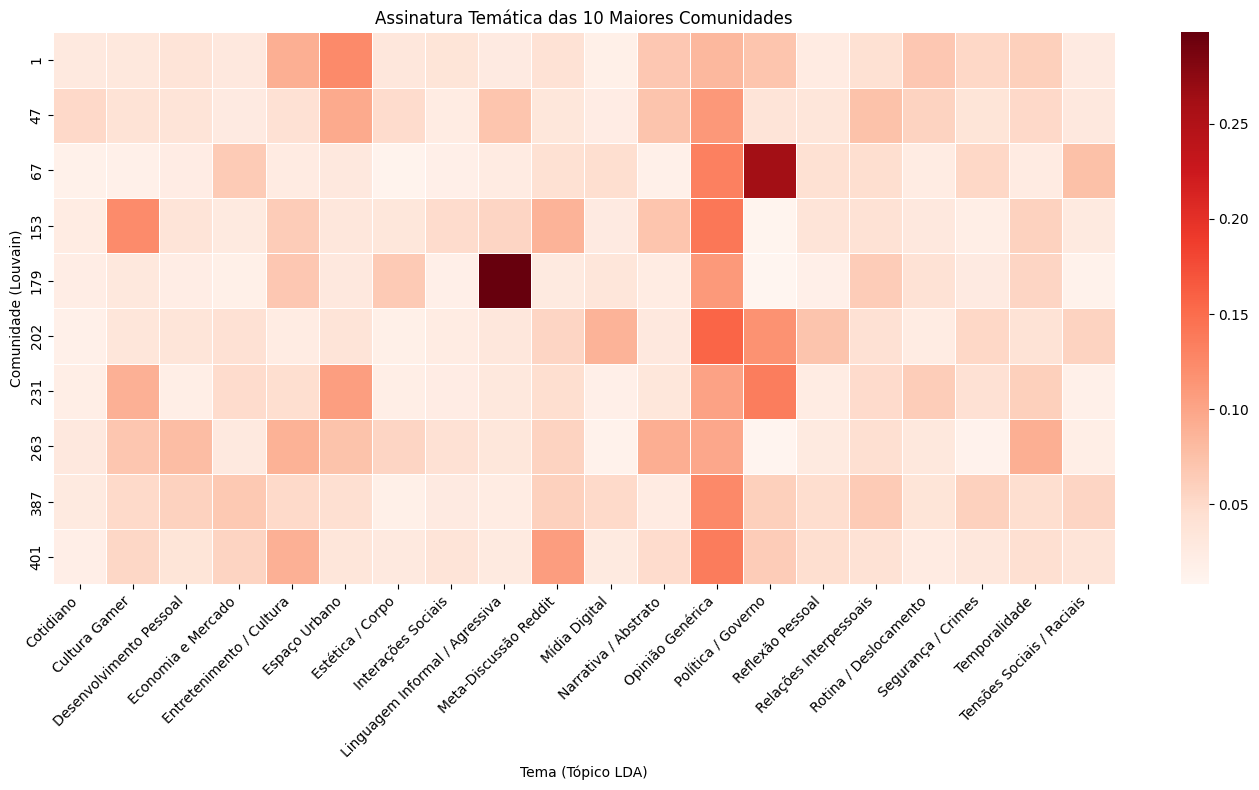

In [6]:
top_10_comunidades = df['louvain_community'].value_counts().nlargest(10).index

df_top_com = df[df['louvain_community'].isin(top_10_comunidades)]
crosstab_temas = pd.crosstab(df_top_com['louvain_community'], df_top_com['tema_nome'])

crosstab_temas_norm = crosstab_temas.div(crosstab_temas.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(crosstab_temas_norm, cmap="Reds", annot=False, linewidths=.5)
plt.title("Assinatura Temática das 10 Maiores Comunidades")
plt.xlabel("Tema (Tópico LDA)")
plt.ylabel("Comunidade (Louvain)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("heatmap_temas_comunidades.png", dpi=300)
plt.show()

In [33]:
df = df[df['author'] != '[deleted]']
mobilidade_autor = df.groupby('author')['louvain_community'].nunique()

print("--- Distribuição de Mobilidade dos Autores ---")
print(mobilidade_autor.value_counts(normalize=True).head(100) * 100) 

autores_exploradores = mobilidade_autor[mobilidade_autor >= 3].index
df_exploradores = df[df['author'].isin(autores_exploradores)]

print("\n--- Temas mais propagados por Autores que cruzam comunidades ---")
print(df_exploradores['tema_nome'].value_counts(normalize=True).head(5) * 100)


--- Distribuição de Mobilidade dos Autores ---
louvain_community
1     91.999410
2      6.448935
3      1.125150
4      0.271371
5      0.092712
6      0.030289
7      0.016759
8      0.007073
9      0.003229
10     0.002460
11     0.000923
12     0.000461
23     0.000308
15     0.000308
13     0.000308
34     0.000154
19     0.000154
Name: proportion, dtype: float64

--- Temas mais propagados por Autores que cruzam comunidades ---
tema_nome
Opinião Genérica            10.908991
Política / Governo          10.366555
Espaço Urbano                6.410608
Entretenimento / Cultura     6.265958
Meta-Discussão Reddit        5.384910
Name: proportion, dtype: float64


In [32]:
# Calcular a média de Score por Tópico em toda a rede
score_por_tema = df.groupby('tema_nome')['score'].median().sort_values(ascending=False)

print("--- Temas que geram maior engajamento (Mediana de Score Geral) ---")
print(score_por_tema.head(5))

comunidade_alvo = 401 
df_com_alvo = df[df['louvain_community'] == comunidade_alvo]
score_com_alvo = df_com_alvo.groupby('tema_nome')['score'].median().sort_values(ascending=False)

print(f"\n--- Temas mais engajados dentro da Comunidade {comunidade_alvo} ---")
print(score_com_alvo.head(5))

--- Temas que geram maior engajamento (Mediana de Score Geral) ---
tema_nome
Narrativa / Abstrato              1653.0
Cultura Gamer                     1565.0
Interações Sociais                1522.0
Espaço Urbano                     1459.0
Linguagem Informal / Agressiva    1409.0
Name: score, dtype: float64

--- Temas mais engajados dentro da Comunidade 401 ---
tema_nome
Política / Governo       3039.0
Economia e Mercado       2511.5
Segurança / Crimes       2206.0
Cotidiano                1784.0
Rotina / Deslocamento    1768.0
Name: score, dtype: float64


In [37]:
df_misoginia = df[df['topico_dominante'] == 12]

# Agrupando por subreddit e comunidade, e contando o volume de posts
distribuicao_misoginia = df_misoginia.groupby(['subreddit', 'louvain_community']).size().reset_index(name='qtd_posts')

# Ordenando para ver quais subreddits mais falam sobre isso 
top_subreddits_misoginia = distribuicao_misoginia.sort_values(by='qtd_posts', ascending=False).head(30)

print("Top Subreddits com maior volume do Tópico 12 (e suas respectivas comunidades):")
print(top_subreddits_misoginia.to_string(index=False))

Top Subreddits com maior volume do Tópico 12 (e suas respectivas comunidades):
          subreddit  louvain_community  qtd_posts
    averageredditor                202        118
          newtubers                478        106
        gcdebatesqt                133         99
           modcoord                333         99
   blackpillscience                 37         95
          youtubers                478         95
         wordington                447         90
        wonderwoman                401         86
     smallytchannel                478         86
     egalitarianism                202         85
      gendercynical                 67         84
             twitch                439         82
   save3rdpartyapps                333         80
        transgender                401         76
   everydaymisandry                202         76
     pornismisogyny                 67         75
          losercity                401         75
     livestreamfail  

Carregando o grafo
Grafo carregado com sucesso: 4873 nós e 11961 arestas.
Destacando 30 subreddits misóginos no grafo...

Calculando a disposição espacial dos nós (Spring Layout)...

Desenhando e renderizando o gráfico colorido...
Gráfico gerado com sucesso em:
destaque_misoginia.png


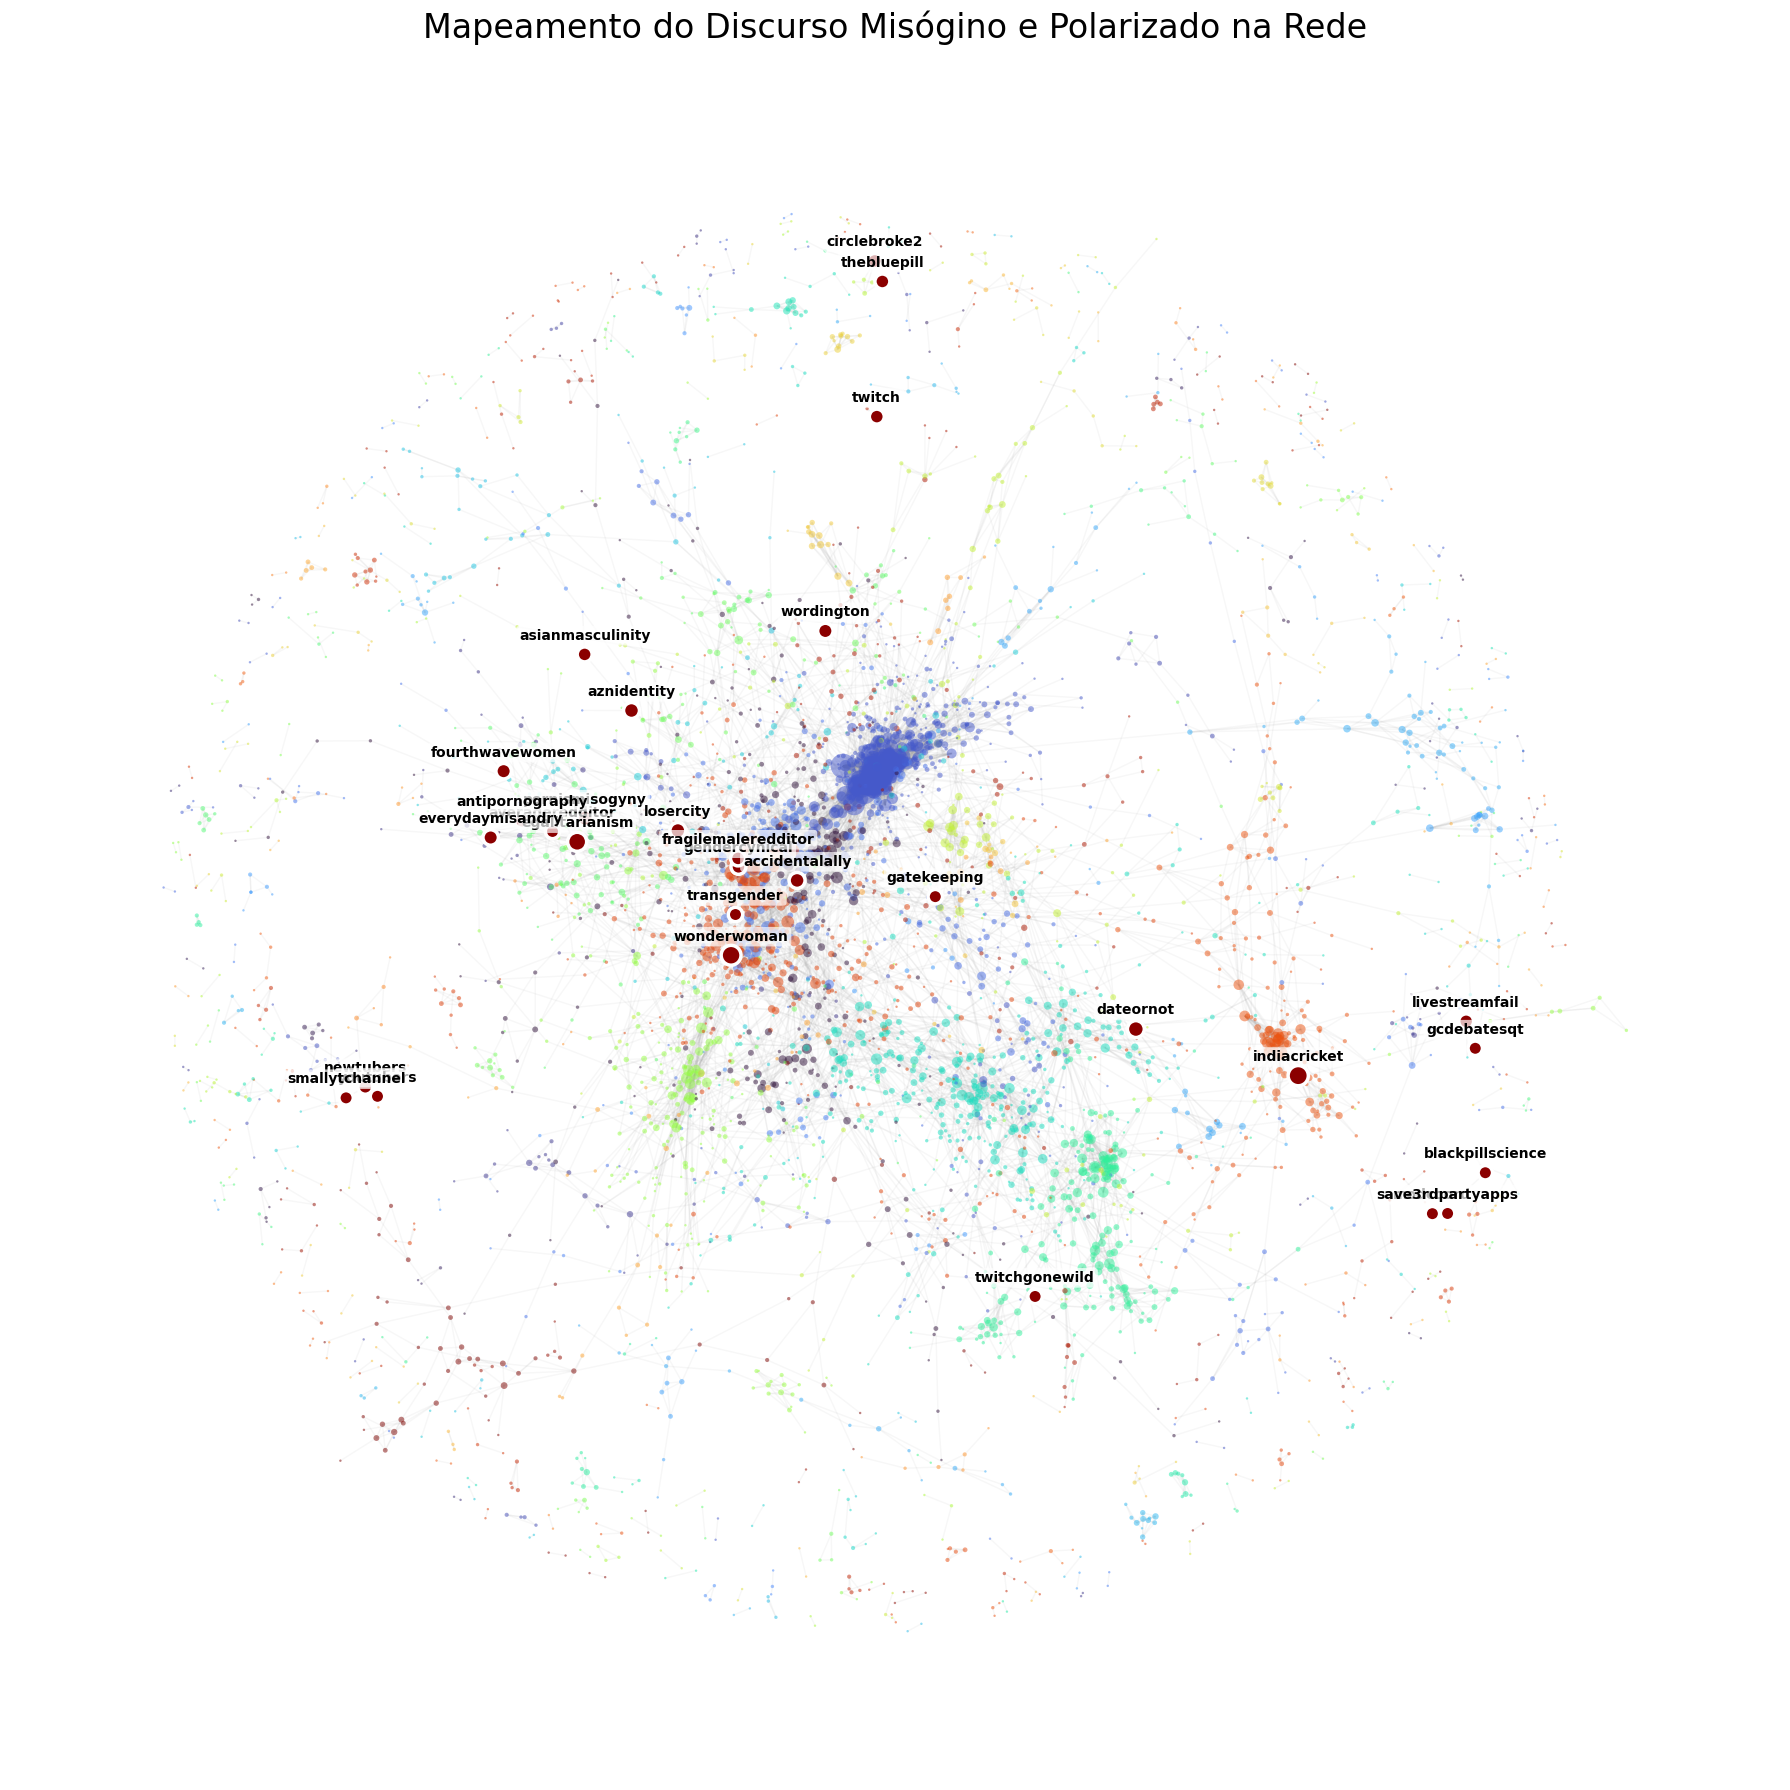

In [41]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_destaque_misoginia():
    print('='*50)
    print("Carregando o grafo")
    
    try:
        G = nx.read_graphml("network_disparity.graphml")
    except FileNotFoundError:
        print("Erro: Arquivo .graphml não encontrado.")
        return

    print(f"Grafo carregado com sucesso: {G.number_of_nodes()} nós e {G.number_of_edges()} arestas.")

    subreddits_alvo = [
        'averageredditor', 'newtubers', 'gcdebatesqt', 'modcoord', 
        'blackpillscience', 'youtubers', 'wordington', 'wonderwoman', 
        'smallytchannel', 'egalitarianism', 'gendercynical', 'twitch', 
        'save3rdpartyapps', 'transgender', 'everydaymisandry', 'pornismisogyny', 
        'losercity', 'livestreamfail', 'asianmasculinity', 'antipornography', 
        'dateornot', 'twitchgonewild', 'indiacricket', 'fragilemaleredditor', 
        'accidentalally', 'circlebroke2', 'aznidentity', 'fourthwavewomen', 
        'thebluepill', 'gatekeeping'
    ]

    nos_destaque = [n for n in subreddits_alvo if n in G.nodes()]
    print(f"Destacando {len(nos_destaque)} subreddits misóginos no grafo...")

    # Recuperar as cores das comunidades salvas no arquivo
    # Tentamos converter para int para o colormap funcionar direitinho
    try:
        node_colors = [int(float(G.nodes[n].get('louvain_community', 0))) for n in G.nodes()]
    except ValueError:
        node_colors = [0 for _ in G.nodes()]

    # Calcular tamanhos
    degrees = dict(G.degree())
    node_sizes = [degrees[n] * 3 for n in G.nodes()] # Tamanho base de todos os nós
    
    # Tamanho super exagerado para os nós alvos para eles saltarem na tela
    tamanhos_destaque = [(degrees[n] * 8) + 100 for n in nos_destaque] 

    print("\nCalculando a disposição espacial dos nós (Spring Layout)...")
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    print("\nDesenhando e renderizando o gráfico colorido...")
    plt.figure(figsize=(18, 18), facecolor='white') 
    
    # Arestas (deixando um pouco mais visíveis que o anterior)
    nx.draw_networkx_edges(G, pos, alpha=0.08, edge_color='#999999')
    
    # 1. Desenha o fundo com as CORES ORIGINAIS (turbo)
    nx.draw_networkx_nodes(
        G, pos, 
        node_size=node_sizes, 
        cmap=plt.cm.turbo, 
        node_color=node_colors, 
        alpha=0.5, # Levemente transparente para o foco ir para os vermelhos
        linewidths=0          
    )

    # 2. Desenha OS ALVOS por cima (Vermelho escuro com borda branca grossa)
    nx.draw_networkx_nodes(
        G, pos, 
        nodelist=nos_destaque,
        node_size=tamanhos_destaque, 
        node_color='darkred', 
        alpha=1.0,
        edgecolors='white',
        linewidths=2.5          
    )

    # 3. Adiciona os textos com uma caixinha de fundo translúcida para não sumir no colorido
    labels_destaque = {n: n for n in nos_destaque}
    for node, label in labels_destaque.items():
        x, y = pos[node]
        plt.text(x, y + 0.015, label, fontsize=10, fontweight='bold', 
                 color='black', ha='center', va='bottom',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

    plt.title("Mapeamento do Discurso Misógino e Polarizado na Rede", color='black', fontsize=24, pad=20)
    plt.axis('off') 

    plt.tight_layout()
    plt.savefig("destaque_misoginia.png", dpi=300, facecolor='white', bbox_inches='tight')
    
    print('='*50)
    print('Gráfico gerado com sucesso em:\ndestaque_misoginia.png')
    print('='*50)

if __name__ == "__main__":
    plot_destaque_misoginia()